# Simulation_CLP_PID_FF


In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors

%config InlineBackend.figure_formats ="svg"
from package_DBR import *
from package_TCLAB import *
from package_LAB import *


## Simulation parameters

In [128]:
#Point de fonctionnement

MV0 = 50
PV0 = 54
DV0 = 50

#Parametre maniupulated value

Kp = 0.374684
T1_p = 171.145985
T2_p = 26.74464
theta_p = 12.00844


#Parmetre Disturbance Value

Kd = 0.3933681
T1_d= 161.75194
T2_d= 36.287948
theta_d= 19.570305



#IMC TUNING
gamma = 0.5
Kc,Ti,Td = IMC_Tuning(Kp, gamma, theta_p, T1_p, T2_p, 2)
print(Kc)
Kc = Kc *0.5
Ti = 0.75 *Ti



alpha = 0.9
MVMin = 0
MVMax = 100
TSim = 1700
Ts = 1
N = int(TSim/Ts) + 1


print("kc = ", Kc)
print("Ti = ", Ti)
print("Td = ", Td)






5.412437356773491
kc =  2.7062186783867457
Ti =  148.41796875
Td =  23.13013947108611


# signals

In [ ]:
scenario = "OLP+FF"



# Scenario 1: CLP + FF
if scenario == "CLP+FF":
    
    ManPath = {0: True, 150: False, TSim: False} 
    MVManPath = {0: MV0+15, TSim: MV0+15} 
    
    SPPath = {0: PV0+10, 900: PV0+5, TSim: PV0+5} 
    DVPath = {0: DV0, 1100: DV0+20, 1200: DV0, TSim: DV0}
    
    ActivateFF = True
    ManFF = False

# Scenario 2: CLP + no FF
if scenario == "CLP+noFF":
    # ManPath = {0: True, 500: False, TSim: False} 
    # MVManPath = {0: MV0, TSim: MV0} 
    # SPPath = {0: PV0+5, 1500: PV0-5, TSim: PV0-5} 
    # DVPath = {0: DV0, 2500: DV0+10, TSim: DV0+10}
    # ActivateFF = False
    # ManFF = False
    ManPath = {0: True, 150: False, TSim: False} 
    MVManPath = {0: MV0+15, TSim: MV0+15} 
    
    SPPath = {0: PV0+10, 900: PV0+5, TSim: PV0+5} 
    DVPath = {0: DV0, 1100: DV0+20, 1200: DV0, TSim: DV0}
    
    ActivateFF = False
    ManFF = False


# Scenario 3: OLP + no FF
if scenario == "OLP+noFF":
    ManPath = {0: True, TSim: True}
    MVManPath = {0: MV0, TSim: MV0}
    SPPath = {0: PV0, TSim: PV0}
    DVPath = {0: 50, 1200: 60,TSim: 60}
    ActivateFF = False
    ManFF = True

# Scenario 4: OLP + FF
if scenario == "OLP+FF":
    ManPath ={0: True, TSim: True}
    MVManPath = {0: MV0, TSim: MV0}
    SPPath ={0: PV0, TSim: PV0}
    DVPath = {0: 50.0, 1200: 60, TSim: 60.0}
    ActivateFF = True
    ManFF = True



## Simulation 

In [130]:






t = []
MV = []

MVP = []
MVI = []
MVD = []

SP=[]
MVMan=[]
MVFF = []
Man =[]
ManFF = []

DV =[]
E = []
PV = []



MVFFDelay = []
MVFFLL_output = []

MVDelayp =[]
PV1p =[]
PV2p =[]

MVDelayd =[]
PV1d =[]
PV2d =[]



for i in range(0,N):

    t.append(i*Ts)
    SelectPath_RT(SPPath,t,SP)
    SelectPath_RT(DVPath,t,DV)
    

    Delay_RT(DV-DV0*np.ones_like(DV), np.max([theta_d-theta_p, 0]), Ts, MVFFDelay)
    LL_RT(MVFFDelay, -Kd/Kp, T1_p, T1_d, Ts, MVFFLL_output)

    if ActivateFF :
        LL_RT(MVFFLL_output, 1, T2_p, T2_d, Ts, MVFF)
    else :
        LL_RT(MVFFLL_output, 0, T2_p, T2_d, Ts, MVFF)

    
    SelectPath_RT(ManPath,t,Man)
    SelectPath_RT(MVManPath,t, MVMan)

    PID_RT(SP, PV, Man, MVMan, MVFF, Kc, Ti, Td, alpha , Ts, MVMin, MVMax, MV, MVP, MVI, MVD, E, ManFF, PV0)

    
    Delay_RT(MV, theta_p, Ts, MVDelayp, MV0)
    FO_RT(MVDelayp, Kp, T1_p, Ts, PV1p,0)
    FO_RT(PV1p, 1, T2_p, Ts, PV2p, 0)



    Delay_RT(DV - DV0*np.ones_like(DV), theta_d, Ts, MVDelayd, 0)
    FO_RT(MVDelayd, Kd, T1_d, Ts, PV1d, 0)
    FO_RT(PV1d, 1, T2_d, Ts, PV2d, 0)

    PV.append(PV2p[-1] + PV2d[-1] + PV0 - Kp*MV0)




# Import Data

In [131]:
nameFile = 'TCLAB_PID_FF_Test_on_2026-03-30-14h57.txt'

titleName = nameFile.split('.')[0]    
data = pd.read_csv('Data/' + nameFile)



t_exp = data['t'].values
MV_exp = data['MV'].values
MVP_exp = data[' MVP'].values
MVI_exp = data[' MVI'].values
MVD_exp = data[' MVD'].values
PV_exp = data['PV'].values   
DV_exp = data['DV'].values
SP_exp = data[' SP'].values 
     

# Plot

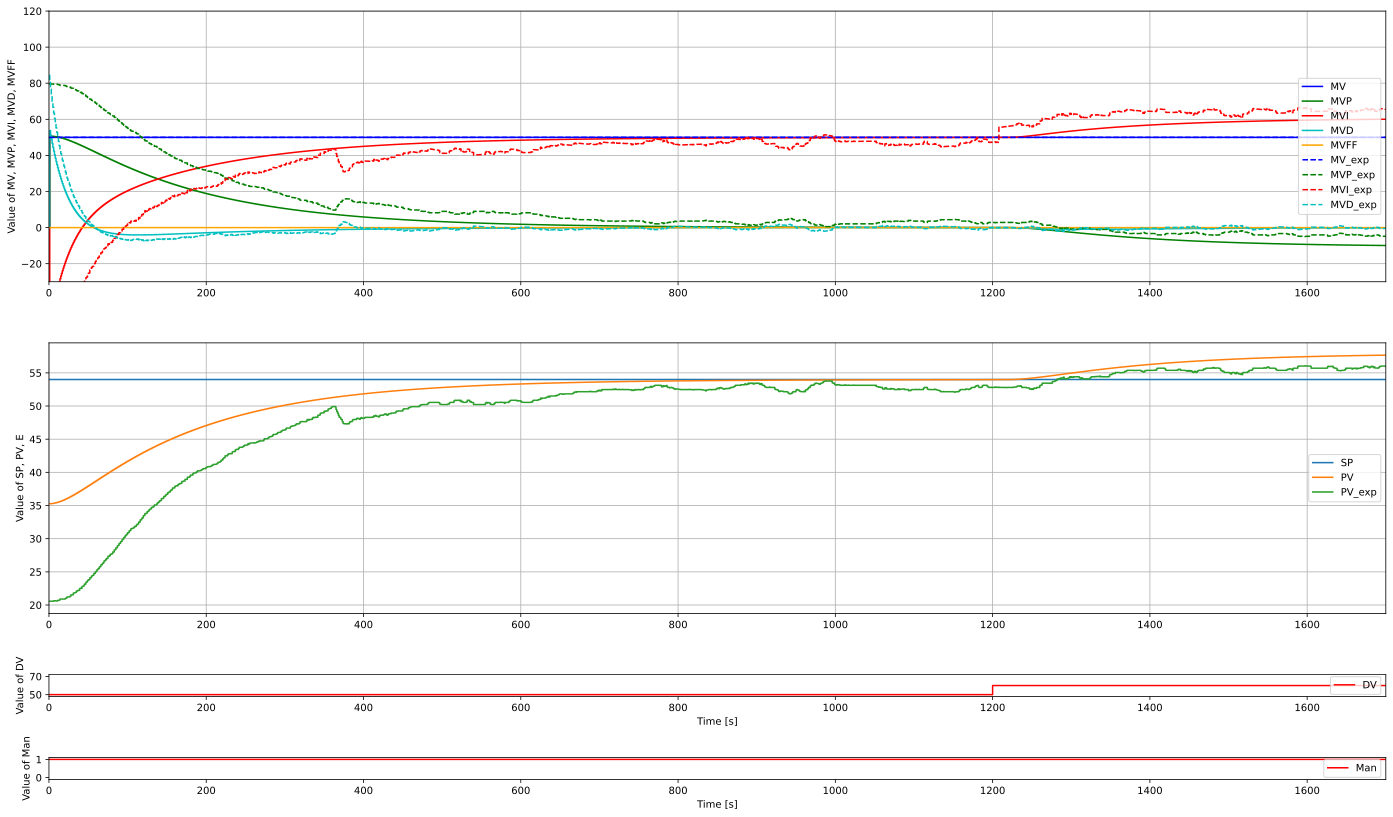

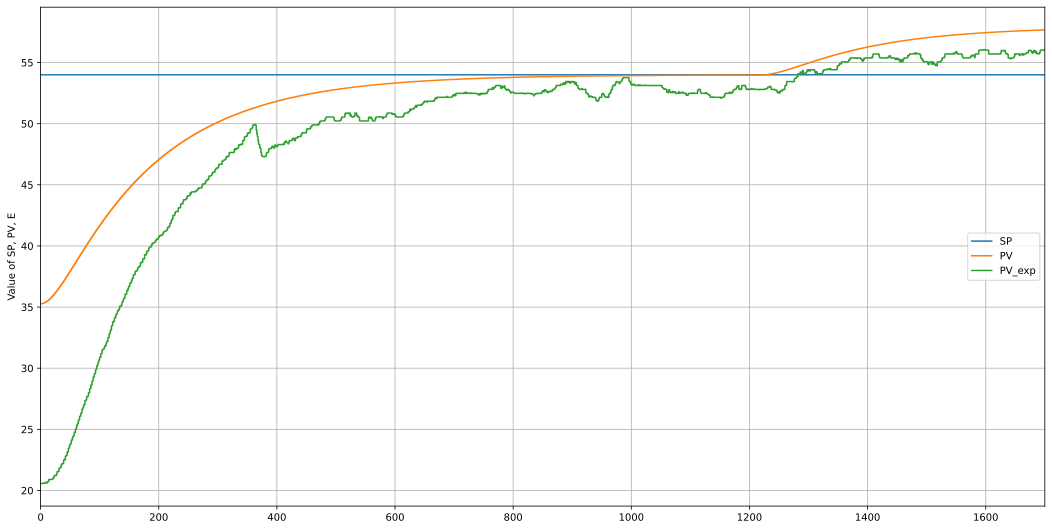

In [132]:



plt.figure(figsize = (20,12))


plt.subplot(10,1,(1,4))
plt.step(t,MV, color= "b",label='MV',where='post' )
plt.step(t,MVP, color= "g" ,label='MVP',where='post' )
plt.step(t,MVI,color= "r" ,label='MVI',where='post')
plt.step(t,MVD,color=  "c",label='MVD',where='post')
plt.step(t,MVFF,label='MVFF', color="orange",where='post')
plt.step(t_exp, MV_exp,color= "b",  label='MV_exp',where='post', linestyle="dashed" )
plt.step(t_exp,MVP_exp,color= "g",  label='MVP_exp',where='post', linestyle='dashed' )
plt.step(t_exp,MVI_exp,color= "r", label='MVI_exp',where='post', linestyle='dashed')
plt.step(t_exp,MVD_exp,color=  "c", label='MVD_exp',where='post', linestyle='dashed')


# plt.step(t,MVDelay,'b-',linewidth=0.5,label='MV plus delay',where='post')
plt.ylabel('Value of MV, MVP, MVI, MVD, MVFF')
plt.legend(loc='right')
plt.xlim([0, TSim])
plt.ylim([-30, 120])
plt.grid()



plt.subplot(10,1,(5,8))
plt.step(t,SP, label='SP',where='post')
plt.step(t,PV, label='PV',where='post')
plt.step(t_exp, PV_exp , label ='PV_exp', where='post')


# plt.step(t,MVDelay,'b-',linewidth=0.5,label='MV plus delay',where='post')
plt.ylabel('Value of SP, PV, E')
plt.legend(loc='right')
plt.xlim([0, TSim])
plt.grid()


plt.subplot(10,1,9)
plt.ylim((48,72))
plt.step(t,DV,'r-',label='DV',where='post')
# plt.step(t,PV_TRAP,'springgreen',label='First order response plus delay (TRAP)',where='post')
plt.ylabel('Value of DV')
plt.xlabel('Time [s]')
plt.legend(loc='right')
plt.xlim([0, TSim])    
plt.yticks((50,70))



plt.subplot(10,1,10)
plt.ylim((-0.1,1.1))
plt.step(t,Man,'r-',label='Man',where='post')
# plt.step(t,PV_TRAP,'springgreen',label='First order response plus delay (TRAP)',where='post')
plt.ylabel('Value of Man')
plt.xlabel('Time [s]')
plt.legend(loc='right')
plt.xlim([0, TSim])  

plt.tight_layout(pad=3.0) # 'pad' defines the space around the figure edges
plt.show()



plt.figure(figsize = (18,9))
plt.step(t,SP, label='SP',where='post')
plt.step(t,PV, label='PV',where='post')
plt.step(t_exp, PV_exp , label ='PV_exp', where='post')


# plt.step(t,MVDelay,'b-',linewidth=0.5,label='MV plus delay',where='post')
plt.ylabel('Value of SP, PV, E')
plt.legend(loc='right')
plt.xlim([0, TSim])
plt.grid()
plt.show()





In [133]:
# import numpy as np
# import matplotlib.pyplot as plt
# from IPython.display import display, clear_output
# import tclab
# import time

# # --- Paramètres de l'expérience ---
# Ts = 1            # Temps d'échantillonnage (s)
# TSim = 600        # Durée totale (s)
# Kc = 2.0          # Gain proportionnel
# Ti = 60.0         # Constante intégrale
# Td = 1.0          # Constante dérivée

# # --- Initialisation des listes de données ---
# t, PV, SP, E = [], [], [], []
# MV, MVP, MVI, MVD, MVFF = [], [], [], [], []
# Man = []

# # --- Configuration du Graphique (Structure 7 rangées) ---
# fig = plt.figure(figsize=(15, 9))

# # Subplot 1 (MV & PID)
# ax1 = plt.subplot(7, 1, (1, 4))
# l_mv, = ax1.step([], [], 'b-', label='MV', where='post', linewidth=2)
# l_mvp, = ax1.step([], [], 'r--', label='MVP', where='post', alpha=0.6)
# l_mvi, = ax1.step([], [], 'g--', label='MVI', where='post', alpha=0.6)
# l_mvd, = ax1.step([], [], 'y--', label='MVD', where='post', alpha=0.6)
# ax1.set_ylabel('MV / PID Components')
# ax1.legend(loc='upper left', ncol=4)
# ax1.set_xlim([0, TSim])
# ax1.set_ylim([-5, 105])
# ax1.grid(True)

# # Subplot 2 (SP, PV, E)
# ax2 = plt.subplot(7, 1, (5, 6))
# l_sp, = ax2.step([], [], 'r-', label='SP', where='post')
# l_pv, = ax2.step([], [], 'b-', label='PV', where='post', linewidth=2)
# l_e, = ax2.step([], [], 'black', label='E', where='post', alpha=0.5)
# ax2.axhline(0, color="black", linestyle='--', alpha=0.3)
# ax2.set_ylabel('Values [°C]')
# ax2.legend(loc='right')
# ax2.set_xlim([0, TSim])
# ax2.set_ylim([15, 80])
# ax2.grid(True)

# # Subplot 3 (Manual mode indicator)
# ax3 = plt.subplot(7, 1, 7)
# l_man, = ax3.step([], [], 'r-', label='Man', where='post')
# ax3.set_xlabel('Time [s]')
# ax3.set_ylabel('Man')
# ax3.set_xlim([0, TSim])
# ax3.set_ylim([-0.1, 1.1])
# ax3.grid(True)

# plt.tight_layout(pad=2.0)

# # --- Boucle de contrôle TCLab ---
# lab = tclab.TCLab()

# try:
#     for i in range(TSim):
#         if i == 0: start_time = time.time()
        
#         # 1. MESURE (Temps réel)
#         current_pv = lab.T1
#         current_sp = 50.0 if i > 10 else 20.0 # Exemple de consigne à 50°C
        
#         # 2. CALCULS PID (Basés sur PV)
#         current_e = current_sp - current_pv
        
#         # Calculs simplifiés (pour l'exemple)
#         val_mvp = Kc * current_e
#         val_mvi = (MVI[-1] + (Kc/Ti) * current_e * Ts) if i > 0 else 0
#         val_mvd = (Kc * Td * (current_e - E[-1]) / Ts) if i > 0 else 0
        
#         val_mv = np.clip(val_mvp + val_mvi + val_mvd, 0, 100) # Saturation 0-100%
        
#         # 3. ACTION
#         lab.Q1(val_mv)
        
#         # 4. STOCKAGE
#         t.append(i * Ts)
#         PV.append(current_pv)
#         SP.append(current_sp)
#         E.append(current_e)
#         MV.append(val_mv)
#         MVP.append(val_mvp)
#         MVI.append(val_mvi)
#         MVD.append(val_mvd)
#         Man.append(0) # 0 = Auto
        
#         # 5. MISE À JOUR DU GRAPHIQUE
#         l_pv.set_data(t, PV)
#         l_sp.set_data(t, SP)
#         l_e.set_data(t, E)
#         l_mv.set_data(t, MV)
#         l_mvp.set_data(t, MVP)
#         l_mvi.set_data(t, MVI)
#         l_mvd.set_data(t, MVD)
#         l_man.set_data(t, Man)
        
#         # Affichage
#         clear_output(wait=True)
#         display(fig)
        
#         # Synchro
#         time.sleep(max(0, Ts - (time.time() - start_time) % Ts))

# finally:
#     lab.close()
#     print("Expérience terminée et TCLab déconnecté.")